# BMW Sales Prediction using Machine Learning

## Import Libraries 

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Load Dataset

In [2]:
df = pd.read_csv()

In [3]:
# show first five rows of dataset 
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


# Preprocessing 

In [4]:
# checking the shape of dataset 
df.shape

(3072, 11)

In [5]:
# checking the columns of dataset 
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

In [6]:
# checking the data types of columns 
df.dtypes

Year                  int64
Month                 int64
Region               object
Model                object
Units_Sold            int64
Avg_Price_EUR         int64
Revenue_EUR           int64
BEV_Share           float64
Premium_Share       float64
GDP_Growth          float64
Fuel_Price_Index    float64
dtype: object

In [7]:
# checking the null values in dataset 
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [8]:
# checking the duplicated values in dataset 
df.duplicated().sum()

np.int64(0)

In [9]:
# info of dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [10]:
# statistical summary of dataset 
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


In [11]:
# checking the unique values of region in dataset 
df['Region'].unique()

array(['Europe', 'China', 'USA', 'RestOfWorld'], dtype=object)

In [12]:
# checking the values of each region 
df['Region'].value_counts()

Region
Europe         768
China          768
USA            768
RestOfWorld    768
Name: count, dtype: int64

In [13]:
# checking the unique values of Model in dataset 
df['Model'].unique()

array(['3 Series', '5 Series', 'X3', 'X5', 'X7', 'i4', 'iX', 'MINI'],
      dtype=object)

In [14]:
# checking the values of each Model
df['Model'].value_counts()

Model
3 Series    384
5 Series    384
X3          384
X5          384
X7          384
i4          384
iX          384
MINI        384
Name: count, dtype: int64

# EDA

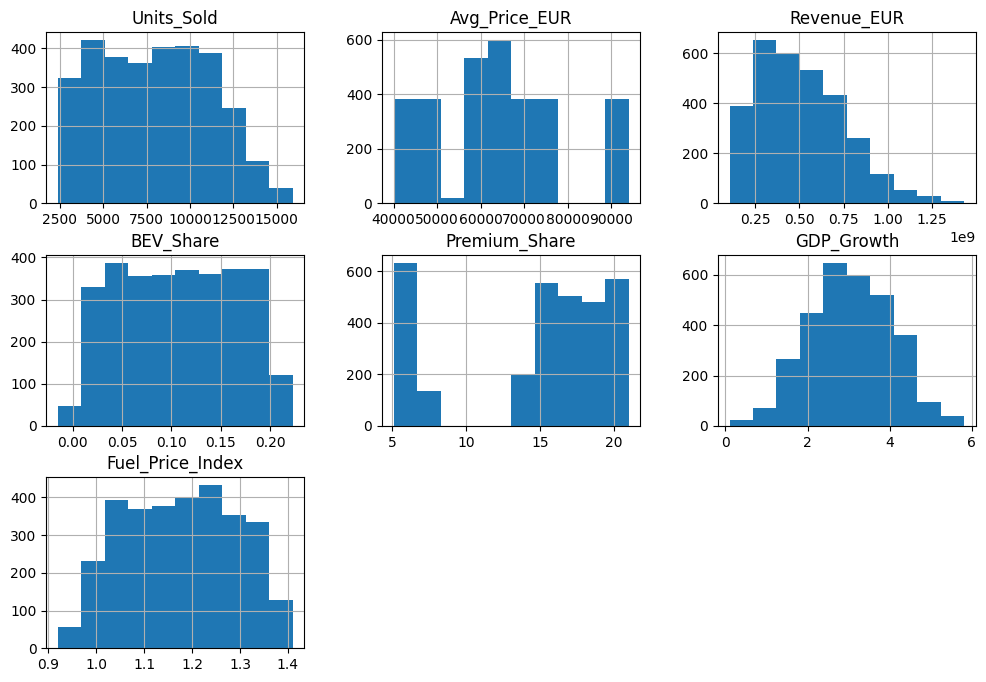

In [15]:
# Distribution of Numerical Features

num_cols = ['Units_Sold','Avg_Price_EUR','Revenue_EUR',
            'BEV_Share','Premium_Share','GDP_Growth','Fuel_Price_Index']

df[num_cols].hist(figsize=(12,8))
plt.show()

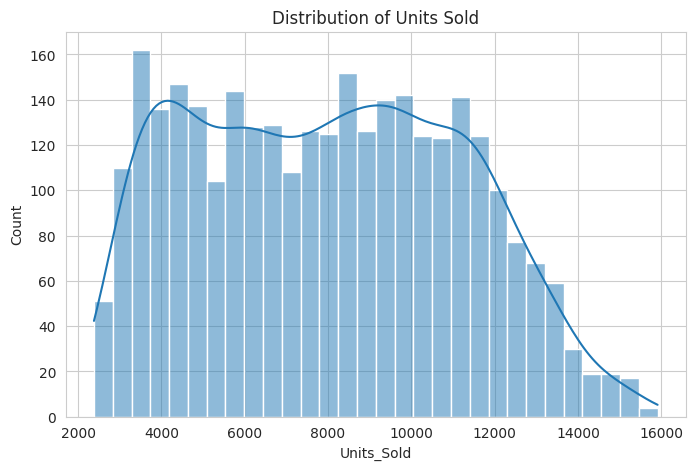

In [16]:
plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")
# Sales Distribution
sns.histplot(df["Units_Sold"], bins=30, kde=True)
plt.title("Distribution of Units Sold")
plt.show()

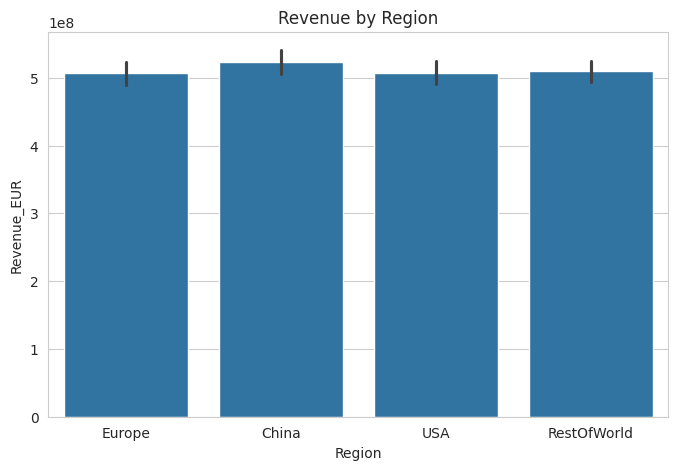

In [17]:
# Revenue by Region
sns.barplot(x="Region", y="Revenue_EUR", data=df)
plt.title("Revenue by Region")
plt.show()

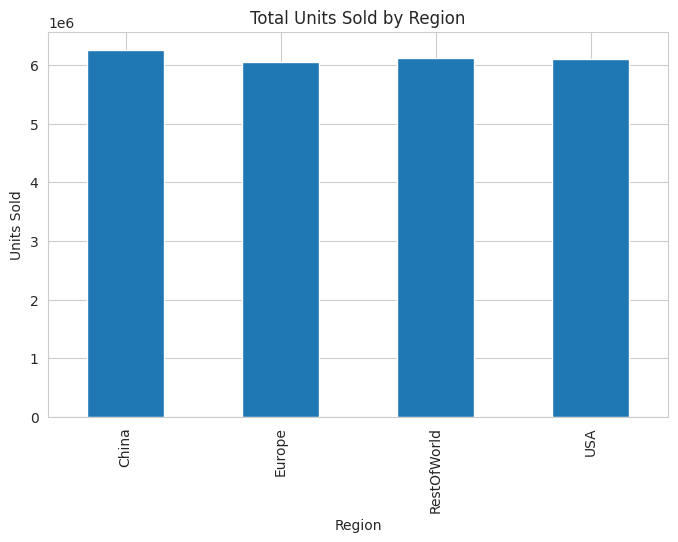

In [18]:
# Sales by Region
region_sales = df.groupby('Region')['Units_Sold'].sum()

region_sales.plot(kind='bar', figsize=(8,5))
plt.title("Total Units Sold by Region")
plt.ylabel("Units Sold")
plt.show()

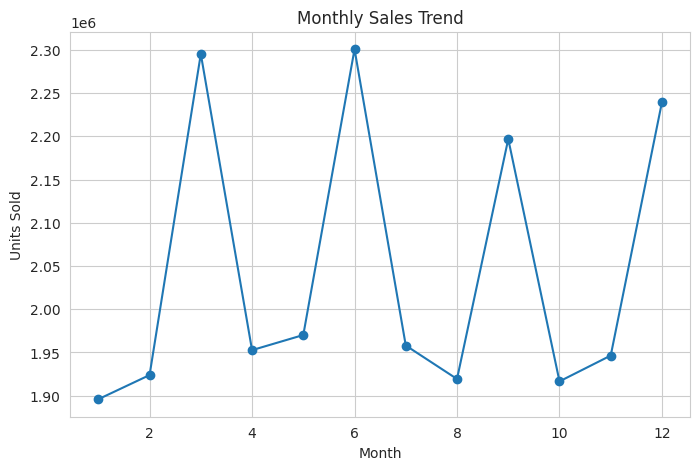

In [19]:
# Monthly Sales Trend
monthly_sales = df.groupby("Month")["Units_Sold"].sum()

monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

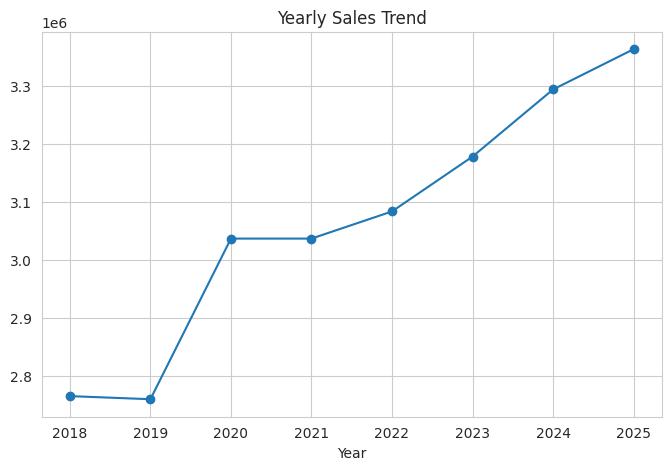

In [20]:
# Yearly Sales Trend
yearly_sales = df.groupby("Year")["Units_Sold"].sum()

yearly_sales.plot(marker="o")
plt.title("Yearly Sales Trend")
plt.show()

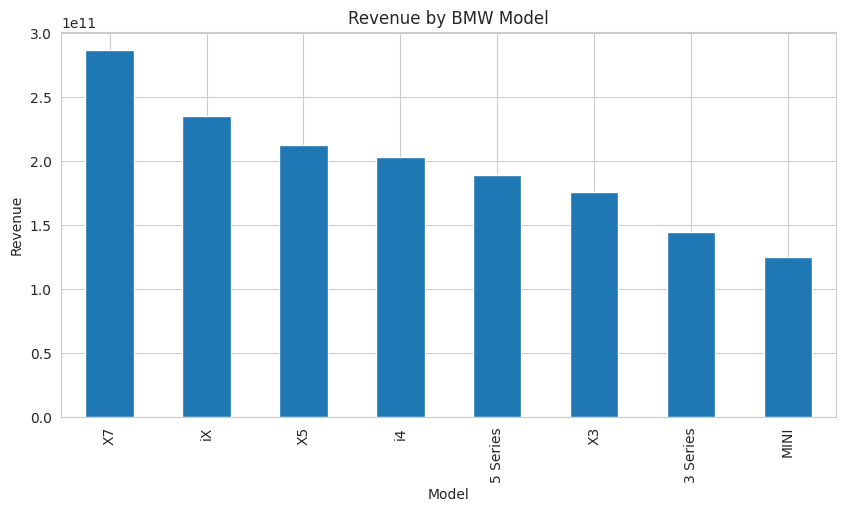

In [21]:
# Revenue by Model
model_revenue = df.groupby('Model')['Revenue_EUR'].sum().sort_values(ascending=False)

model_revenue.plot(kind='bar', figsize=(10,5))
plt.title("Revenue by BMW Model")
plt.ylabel("Revenue")
plt.show()

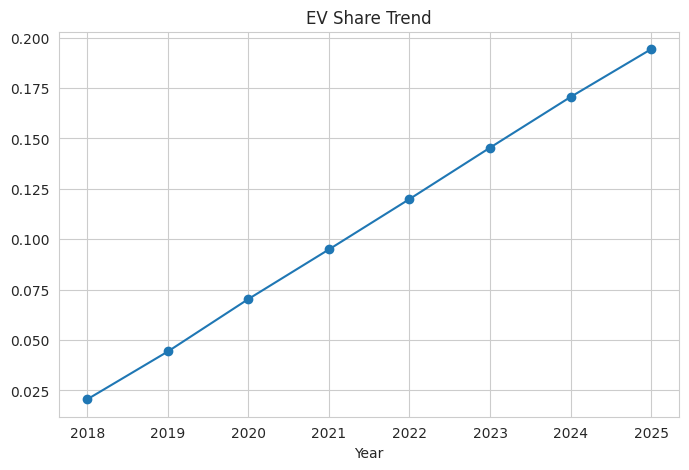

In [22]:
# EV Adoption Trend
ev_trend = df.groupby("Year")["BEV_Share"].mean()

ev_trend.plot(marker="o")
plt.title("EV Share Trend")
plt.show()

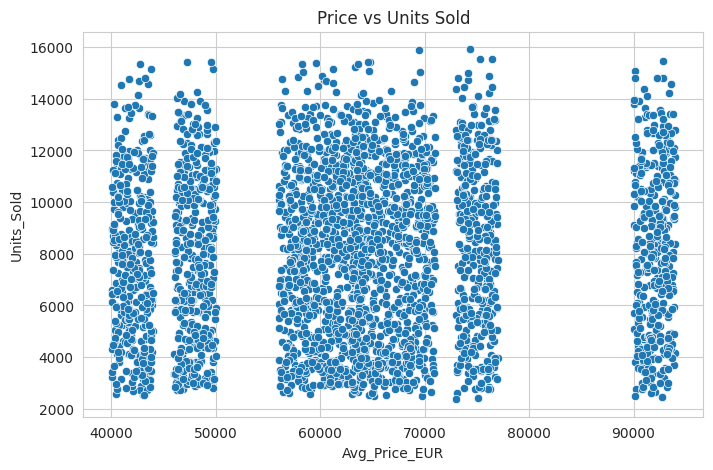

In [23]:
# Average Price vs Units Sold
sns.scatterplot(x="Avg_Price_EUR", y="Units_Sold", data=df)
plt.title("Price vs Units Sold")
plt.show()

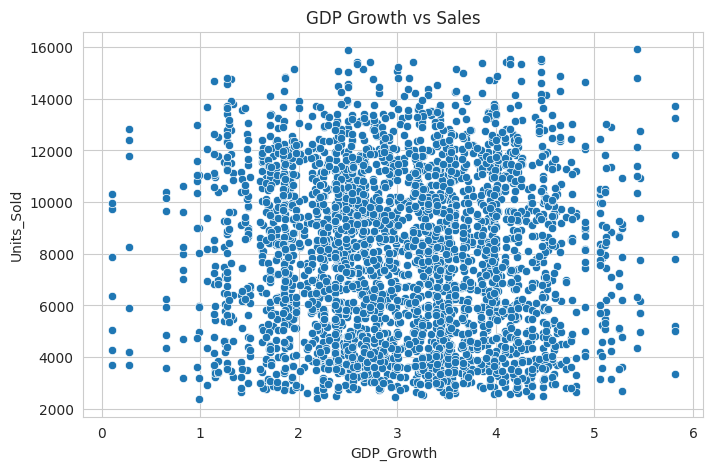

In [24]:
# GDP Growth vs Sales
sns.scatterplot(x="GDP_Growth", y="Units_Sold", data=df)
plt.title("GDP Growth vs Sales")
plt.show()

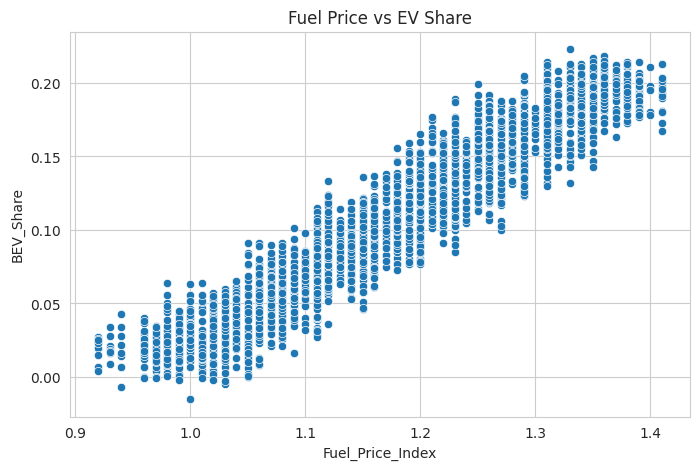

In [25]:
# Fuel Price vs EV Share
sns.scatterplot(x="Fuel_Price_Index", y="BEV_Share", data=df)
plt.title("Fuel Price vs EV Share")
plt.show()

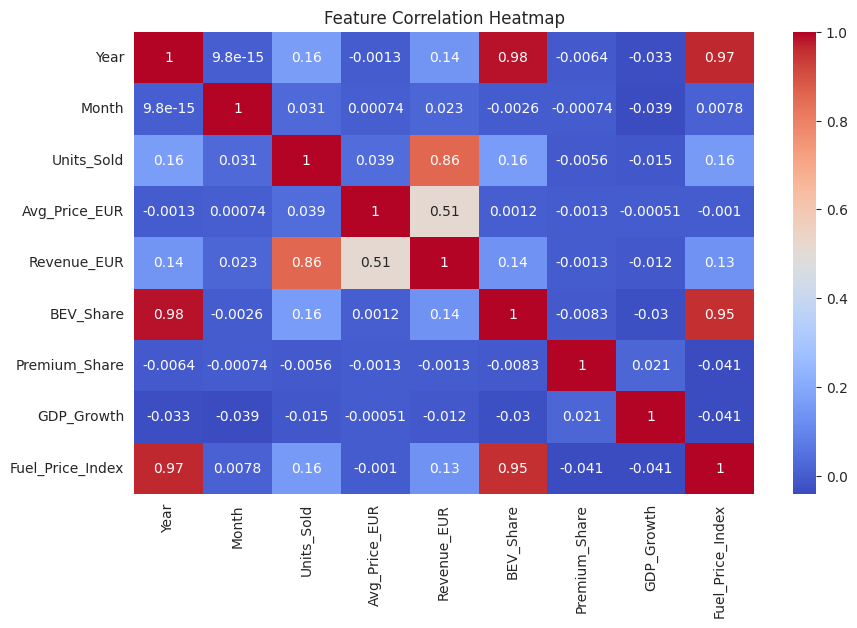

In [26]:
# Correlation Analysis
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

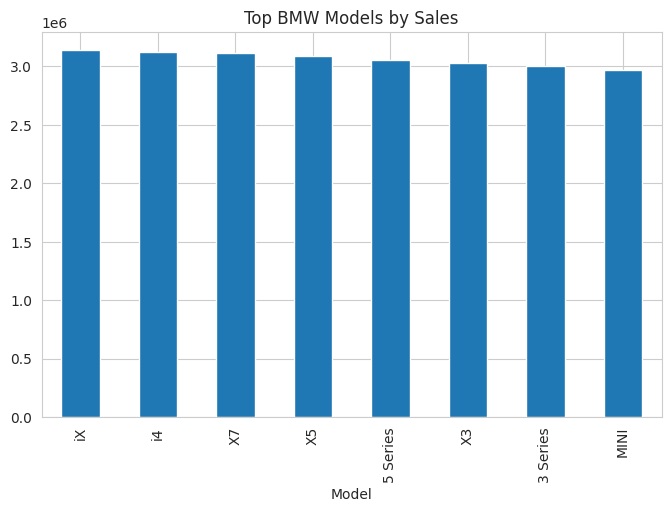

In [27]:
# Top BMW Models by Sales
top_models = df.groupby("Model")["Units_Sold"].sum().sort_values(ascending=False)

top_models.plot(kind="bar")
plt.title("Top BMW Models by Sales")
plt.show()

# Encode Categorical Variables

Columns like Region and Model must be converted to numbers.

In [28]:
le = LabelEncoder()

df['Region'] = le.fit_transform(df['Region'])
df['Model'] = le.fit_transform(df['Model'])

# Define Features and Target

In [29]:
X = df.drop("Units_Sold", axis=1)
y = df["Units_Sold"]

# Train Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define Models

In [31]:
models = {
    
    "Linear Regression": LinearRegression(),
    
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [32]:
# Train Models and Compare Results
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    r2 = r2_score(y_test, predictions)
    
    mse = mean_squared_error(y_test, predictions)
    
    mae = mean_absolute_error(y_test, predictions)
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MSE": mse,
        "MAE": mae
    })

results_df = pd.DataFrame(results)

print(results_df)

               Model  R2 Score            MSE         MAE
0  Linear Regression  0.952169  475401.094303  480.230438
1      Decision Tree  0.992430   75237.764228  178.544715
2      Random Forest  0.998201   17882.618794   82.848065
3  Gradient Boosting  0.996840   31407.828465  130.484381


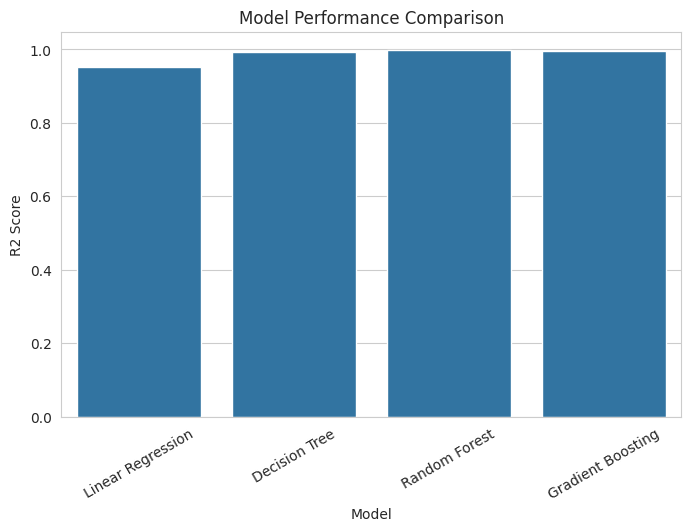

In [33]:
sns.barplot(x="Model", y="R2 Score", data=results_df)

plt.title("Model Performance Comparison")

plt.xticks(rotation=30)

plt.show()

In [34]:
best_model = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(best_model)

               Model  R2 Score            MSE         MAE
2      Random Forest  0.998201   17882.618794   82.848065
3  Gradient Boosting  0.996840   31407.828465  130.484381
1      Decision Tree  0.992430   75237.764228  178.544715
0  Linear Regression  0.952169  475401.094303  480.230438


# Conclusion
This project analyzed global vehicle sales data of the BMW Group from 2018 to 2025 using machine learning techniques. The dataset included important variables such as region, model type, vehicle price, revenue, electric vehicle share, premium market share, GDP growth, and fuel price index. Through exploratory data analysis, important patterns and relationships between economic indicators and vehicle sales were identified.

Several machine learning models were trained to predict the number of vehicles sold (Units_Sold). The models included Linear Regression, Decision Tree, Random Forest, and Gradient Boosting. Their performance was evaluated using three common regression metrics: R² Score, Mean Squared Error (MSE), and Mean Absolute Error (MAE).

The results show that the Random Forest model achieved the best performance, with an R² score of 0.998, the lowest error values (MSE = 17882.61 and MAE = 82.85) among all models. This indicates that Random Forest was able to capture complex relationships between sales, pricing, regional demand, and economic indicators more effectively than the other models. Gradient Boosting and Decision Tree models also performed well but had slightly higher error values. In contrast, Linear Regression produced the lowest accuracy, suggesting that the relationship between the variables is not purely linear.

Overall, the results demonstrate that ensemble-based machine learning models are highly effective for predicting automotive sales in complex market environments. The developed model can help understand sales trends, evaluate the impact of economic factors, and support data-driven decision making in the premium automotive industry. Future work could further improve the model by incorporating additional real-world factors such as consumer demand trends, marketing strategies, and global supply chain conditions.